## Quantitative Framework Used for the Categorical Partitioning of Color Spaces

The challenge with creating a synthetic dataset for categorizing colors is determining our base cases and main color categories.

Thus, previous research on color categorization will prove useful for the development of our dataset. For this project, we will be using [Paul Centore's sRGB Centroids for the ISCC-NBS Color System](https://munsellcolorscienceforpainters.com/ColourSciencePapers/sRGBCentroidsForTheISCCNBSColourSystem.pdf) as our basis for categorization.

The colors listed in the ICSSNBS level 3 color system are usually structured as modifier/s + hue + 'ish' + hue. Thus, if we wanted to identify all the colors identified as, for example, blue, we would look for all the colors that have either "bluish" or "blue" in the name. Let's go ahead and analyze all the colors in the ICSSNBS level 3 color system.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('../datasets/isccnbs_color_categories.csv')

In [2]:
# The first thing I want to do is manually analyze the subwords used to describe colors in the dataset.

name_col = 'ISCC-NBS Level 3 Name'
tokens = (
    df[name_col]
    .dropna()
    .astype(str)
    .str.lower()
    .str.findall(r"[a-z]+")
    .explode()
)
word_counts = tokens.value_counts()

all_subwords_df = (
    word_counts
    .rename_axis('subword')
    .reset_index(name='count')
)

pd.set_option('display.max_rows', None)
all_subwords_df

,subword,count
0,dark,47
1,green,47
2,light,42
3,grayish,36
4,yellow,35
5,blue,33
6,purplish,33
7,deep,29
8,yellowish,28
9,reddish,27


In [3]:
# From the table above, we can observe some modifiers like "dark", "light", "pale", "vivid", "deep", "very", "moderate", "strong", and "brilliant". These modifiers likely indicate the intensity or saturation of the color.
# However, we're more interested in the base color words, which are the most common subwords in the dataset. These include "white", "gray", "blue", but also words like "bluish", "reddish", ...
# For larger datasets, we might want to automate this process, but for this dataset, manual is fine.
# Let's manually build this dictionary of base color words and their corresponding subwords:

"""
You can try using this dictionary, but i find the ambiguity too strong.
Besides, it will learn ambiguity anyway during the training step,
so we'll use the simplified version of the dictionary for now,
which only includes the base color words without their modifiers.

color_categories = {
    'red': ['reddish', 'red'],
    'orange': ['orange'],
    'yellow': ['yellow', 'yellowish'],
    'green': ['green', 'greenish'],
    'blue': ['blue'],
    'violet': ['violet'],
    'purple': ['purplish', 'purple'],
    'white': ['white'],
    'gray': ['grayish', 'gray'],
    'black': ['black', 'blackish'],
    'pink': ['pink', 'pinkish'],
    'brown': ['brown', 'brownish'],
    'olive': ['olive']
}
"""

color_categories_simplified = {
    'red': ['red'],
    'orange': ['orange'],
    'yellow': ['yellow'],
    'green': ['green'],
    'blue': ['blue'],
    'violet': ['violet'],
    'purple': ['purple'],
    'white': ['white'],
    'gray': ['gray'],
    'black': ['black'],
    'pink': ['pink'],
    'brown': ['brown'],
    'olive': ['olive']
}

### Visualizing Color Distributions in CIELAB

Colors are plotted on a **CIELAB hue–lightness plane** (h_ab vs L*) because CIELAB is a perceptually uniform color space: equal distances in L*a*b* correspond more closely to equal perceived color differences than other color systems.

- **x-axis**: CIELAB hue angle h_ab = atan2(b*, a*), in degrees [0°, 360°]
- **y-axis**: CIELAB lightness L* (0 = black, 100 = white)
- **point size**: CIELAB chroma C*_ab = √(a*² + b*²) — larger points are more vivid
- **centroid**: averaged directly in CIELAB space (since a* and b* are Cartesian)


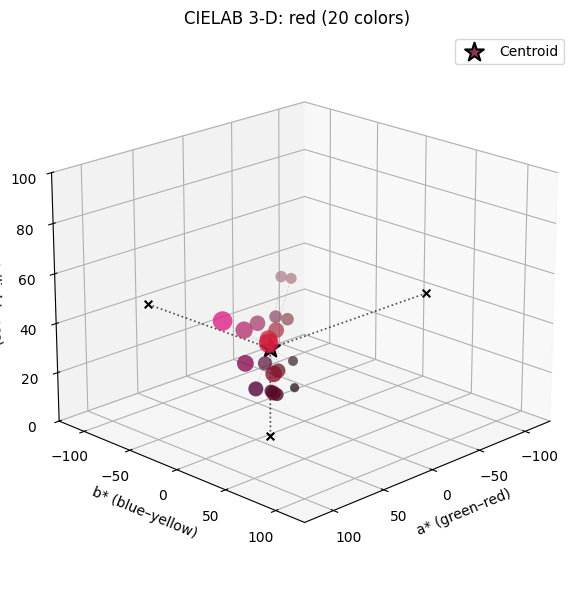

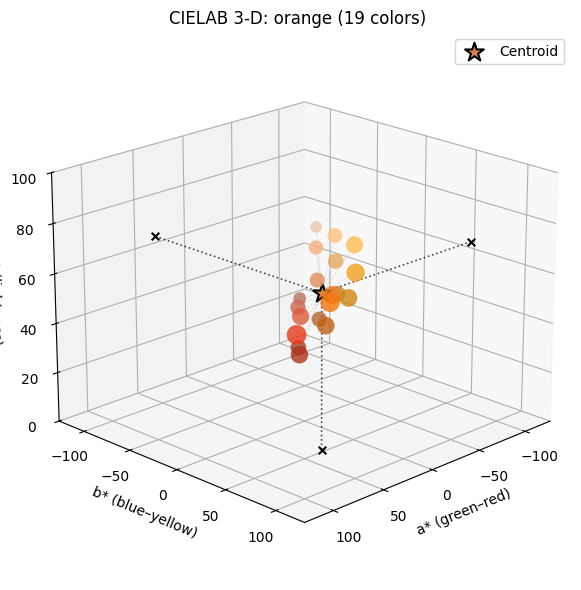

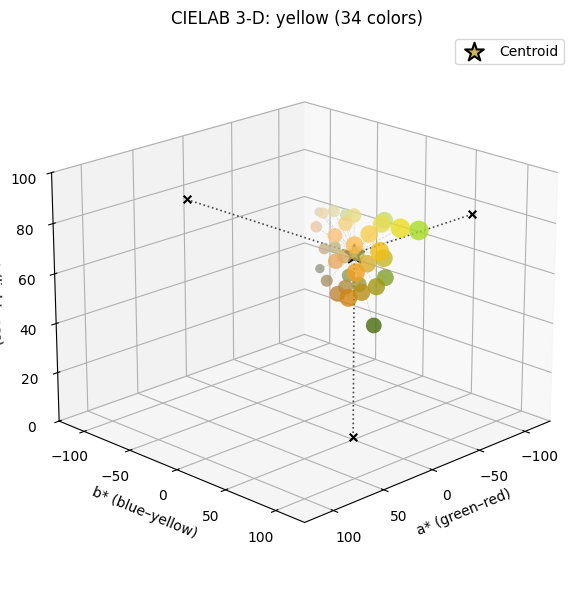

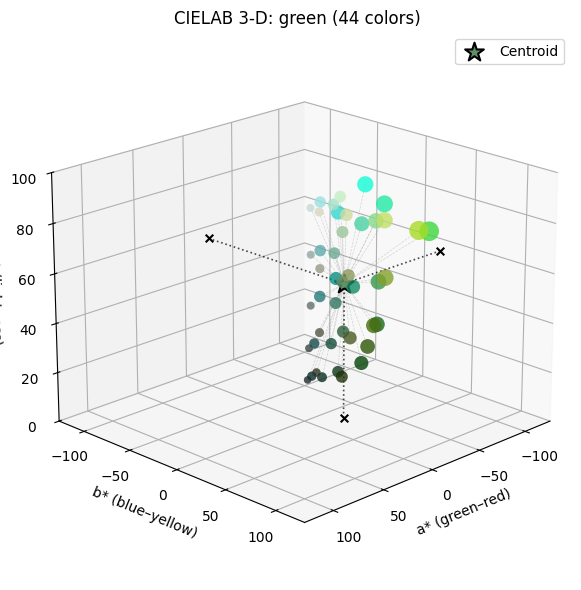

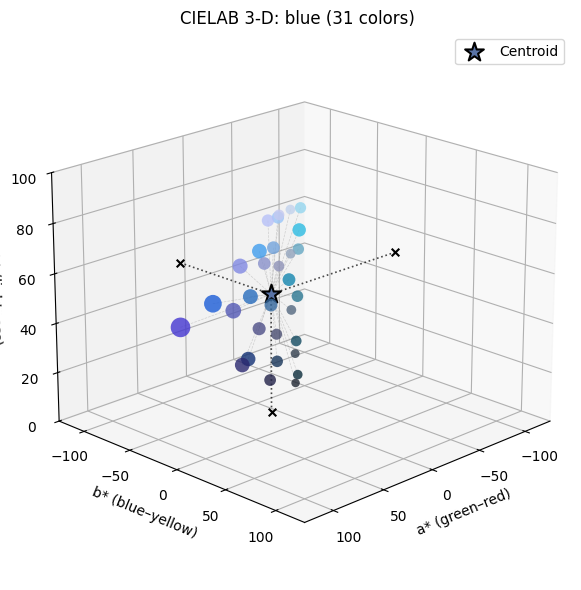

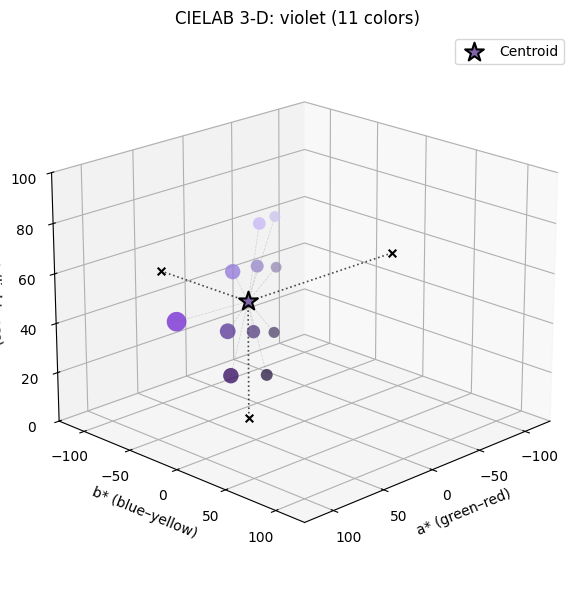

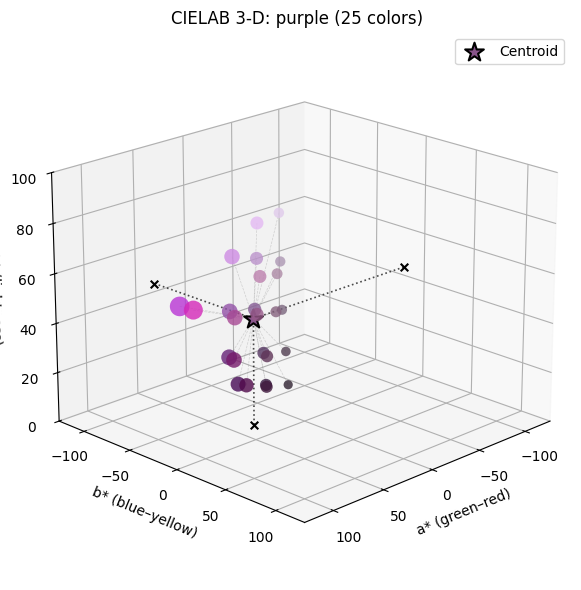

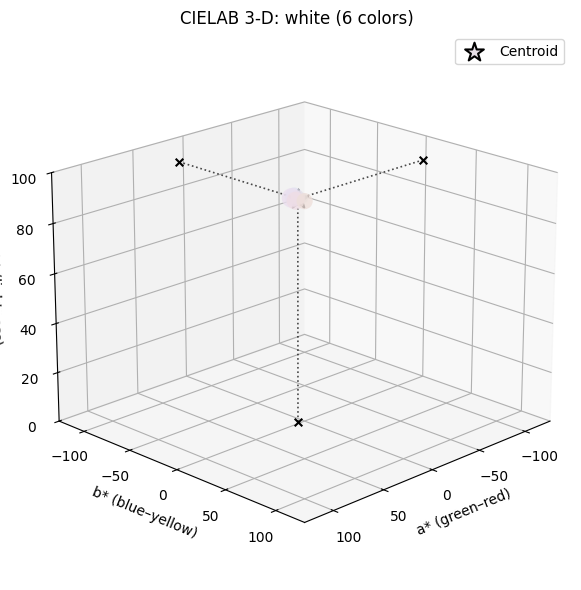

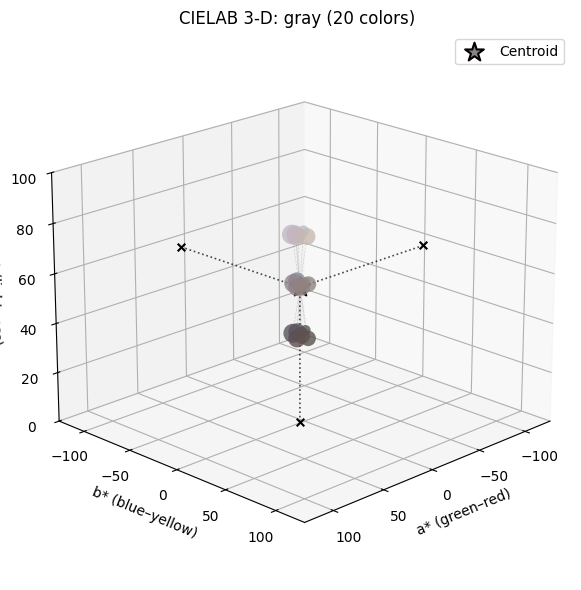

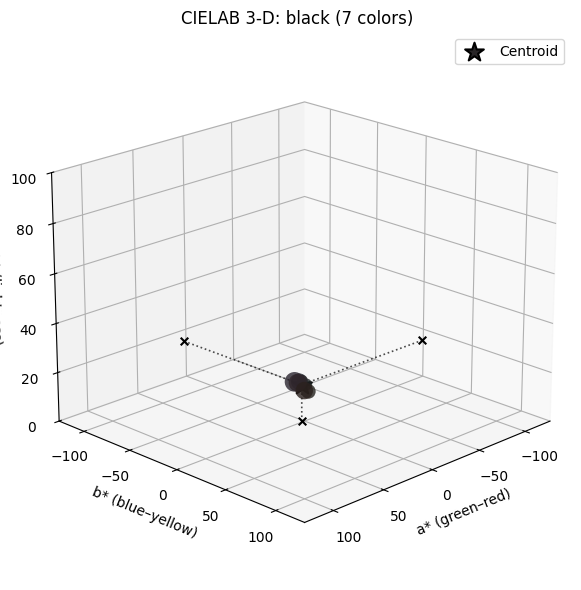

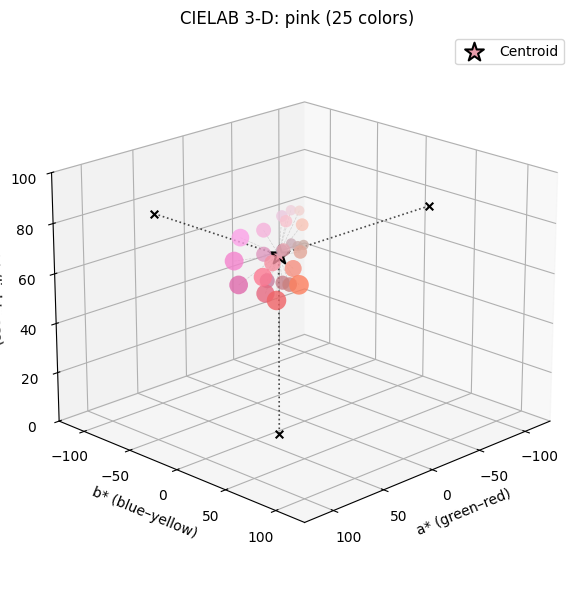

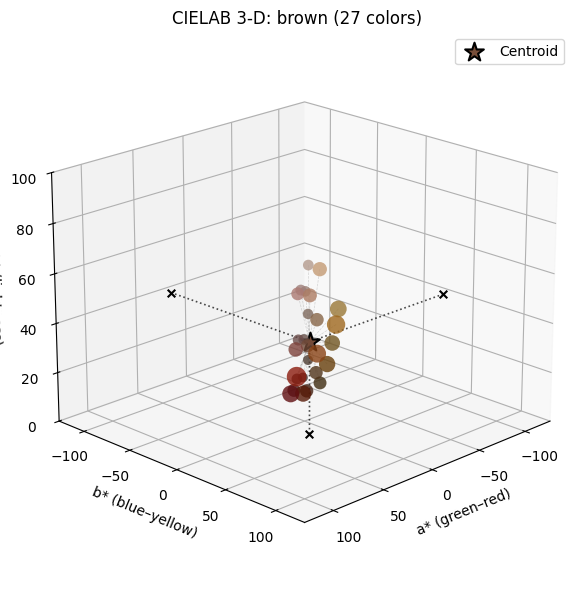

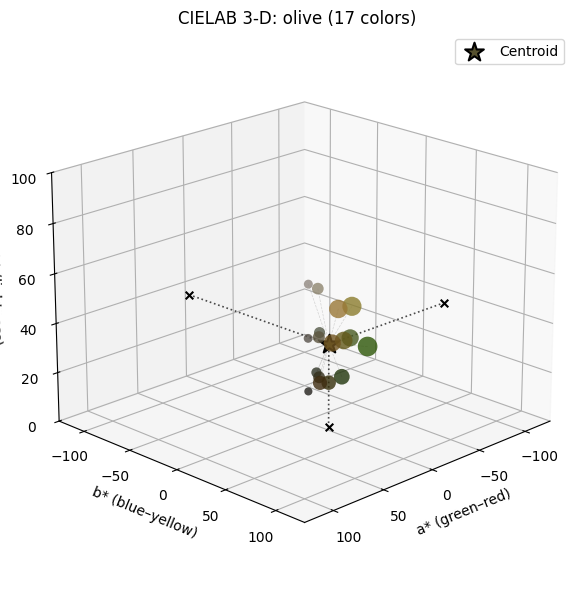

In [ ]:
# Using the simplified dictionary, we can now analyze the colors in each category and visualize them.

import sys
import os
import importlib

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import utils.color_utils as color_utils
importlib.reload(color_utils)
ColorLibrary = color_utils.ColorLibrary

# Instantiate the library
cl_simplified = ColorLibrary(
    csv_path="../datasets/isccnbs_color_categories.csv",
    color_categories=color_categories_simplified,
    name_col='ISCC-NBS Level 3 Name',
    hex_col='hex'
 )

for category in color_categories_simplified.keys():
    """
    cl_simplified.plot_category_hue_lightness(
        category,
        show_centroid=True,
        centroid_color='white',
        centroid_size=1000 
    )
    """
    cl_simplified.plot_category_lab_3d(category, show_centroid=True, draw_lines_to_centroid=True)

In [5]:
# The dataset may be imbalanced, but that won't matter since we can even that out during the generation process. 
cl_simplified.save_as_csv('../datasets/categorized_colors.csv')

Saved 286 entries to ../datasets/categorized_colors.csv
